In [1]:
from __future__ import annotations
import glob
import os
from typing import Iterable, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap
from adjustText import adjust_text
# Try to use OpenStreetMap for images. Taken from
# https://makersportal.com/blog/2020/4/24/geographic-visualizations-in-python-with-cartopy
import cartopy.io.img_tiles as cimgt
import io
from urllib.request import urlopen, Request
from PIL import Image

In [2]:
# ---------- Parsing / normalization ----------

PN_TO_PIPS = {
    "PN1A": "PIPS1A", "PN1B": "PIPS1B",
    "PN2A": "PIPS2A", "PN2B": "PIPS2B",
    "PN3A": "PIPS3A", "PN3B": "PIPS3B",
    # Handle underscore variants (PN_1A, PN_2A, etc.)
    "PN_1A": "PIPS1A", "PN_1B": "PIPS1B",
    "PN_2A": "PIPS2A", "PN_2B": "PIPS2B",
    "PN_3A": "PIPS3A", "PN_3B": "PIPS3B",
}
# Also accept already-normalized names:
PIPS_NAMES = {"PIPS1A", "PIPS1B", "PIPS2A", "PIPS2B", "PIPS3A", "PIPS3B"}

# Note, the following are keyed by the IOP start date. For deployments that occur
# in early morning hours (0-6 UTC) on the day after an IOP start, they will be
# assigned to the previous day's IOP to handle cases where IOPs extend past midnight.
# EDIT: changed this back to being keyed by the IOP start date. Need to fix logic elsewhere.
iop_by_date = {
    "2025-05-18": "IOP1",
    "2025-05-19": "IOP2",
    "2025-05-23": "IOP3",
    "2025-05-25": "IOP4",
    "2025-05-26": "IOP5",
    "2025-05-27": "IOP6",
    "2025-05-29": "IOP7",
    "2025-06-02": "IOP8",
    "2025-06-03": "IOP9",
    "2025-06-04": "IOP10",
    "2025-06-05": "IOP11",
    "2025-06-06": "IOP12",
    "2025-06-08": "IOP13",
    "2025-06-11": "IOP14",
    "2025-06-12": "IOP15",
    "2025-06-13": "IOP16",
    "2025-06-14": "IOP17",
    "2025-06-15": "IOP18",
    "2025-06-17": "IOP19",
    "2025-06-20": "IOP20",
    "2025-06-22": "IOP21",
    "2025-06-24": "IOP22",
    "2025-06-27": "IOP23",
    "2025-06-28": "IOP24",
}

In [ ]:
def image_spoof(self, tile): # this function pretends not to be a Python script
    url = self._image_url(tile) # get the url of the street map API
    req = Request(url) # start request
    req.add_header('User-agent','Anaconda 3') # add user agent to request
    fh = urlopen(req)
    im_data = io.BytesIO(fh.read()) # get image
    fh.close() # close url
    img = Image.open(im_data) # open image with PIL
    img = img.convert(self.desired_tile_form) # set image format
    return img, self.tileextent(tile), 'lower' # reformat for cartopy


def normalize_probe(raw: str) -> Optional[str]:
    """Map PN* or PIPS* to canonical PIPS names; return None for non-PIPS devices."""
    if raw is None or pd.isna(raw):
        return None
    raw = str(raw).strip().upper()

    # First check direct mapping
    if raw in PN_TO_PIPS:
        return PN_TO_PIPS[raw]
    if raw in PIPS_NAMES:
        return raw

    # Handle flexible underscore patterns: PN_1A, PN1A, PN_1_A, etc.
    # Remove underscores and try to match PN[1-3][A-B] pattern
    clean_raw = raw.replace("_", "")
    if clean_raw in PN_TO_PIPS:
        return PN_TO_PIPS[clean_raw]
    if clean_raw in PIPS_NAMES:
        return clean_raw

    return None  # e.g., HP2_4 → ignore for now


def read_deployments(
    files: Iterable[str],
    assume_utc: bool = True,
) -> pd.DataFrame:
    """
    Read headerless CSVs like:
        timestamp,ACTION,ID,lat,lon
    and return a tidy DataFrame with DEPLOY rows only:
        ['source','timestamp','date','probe','lat','lon']

    Notes:
    - RETRIEVE rows may lack lat/lon; they are ignored.
    - Only PIPS probes are kept (PN* mapped to PIPS*).
    """
    frames = []
    for f in files:
        # The example shows 5 fields for DEPLOY and 3 for RETRIEVE.
        # We'll read liberally, then coerce columns by position.
        df = pd.read_csv(
            f,
            header=None,
            names=["timestamp","action","probe","lat","lon"],
            dtype={"timestamp":"string","action":"string","probe":"string"},
            on_bad_lines="skip"
        )

        # Keep only DEPLOY rows
        df = df[df["action"].str.upper() == "DEPLOY"].copy()

        # Parse time
        ts = pd.to_datetime(df["timestamp"], errors="coerce", utc=assume_utc)
        df["timestamp"] = ts
        df = df.dropna(subset=["timestamp"])

        # Coerce coords (RETRIEVE rows would be NaN anyway; we filtered action)
        df["lat"] = pd.to_numeric(df["lat"], errors="coerce")
        df["lon"] = pd.to_numeric(df["lon"], errors="coerce")
        df = df.dropna(subset=["lat","lon"])

        # Normalize probe names; keep only PIPS
        df["probe"] = df["probe"].map(normalize_probe)
        df = df.dropna(subset=["probe"])

        df["source"] = os.path.basename(f)
         # existing date extraction
        df["date"] = df["timestamp"].dt.strftime("%Y-%m-%d")

        # --- NEW: dictionary-based IOP assignment with early morning logic ---
        # For deployments in early morning hours (0-6 UTC), check if they belong to previous day's IOP
        # Also handle cases where multiple files exist for the same date from different IOPs
        iop_list = []
        for idx, row in df.iterrows():
            deployment_date = row["date"]
            deployment_time = row["timestamp"]

            # Strategy: For early morning deployments (0-6 UTC), check if this is likely
            # a continuation of the previous day's IOP by looking at file creation context
            if deployment_time.hour <= 6:
                prev_date = (deployment_time - pd.Timedelta(days=1)).strftime("%Y-%m-%d")

                # If there's an IOP for the previous day, we need to decide if this deployment
                # belongs to that IOP or a new one starting on the current date
                if prev_date in iop_by_date and deployment_date in iop_by_date:
                    # Both dates have IOPs - use time to decide
                    # Deployments before 6 UTC likely belong to previous day's IOP
                    iop_list.append(iop_by_date[prev_date])
                elif prev_date in iop_by_date:
                    # Only previous day has IOP
                    iop_list.append(iop_by_date[prev_date])
                else:
                    # Fall back to deployment date
                    iop_list.append(iop_by_date.get(deployment_date, None))
            else:
                # For deployments after 6 UTC, use the deployment date
                iop_list.append(iop_by_date.get(deployment_date, None))

        df["iop"] = iop_list

        # sanity bounds
        df = df[(df["lat"].between(-90, 90)) & (df["lon"].between(-180, 180))]

        frames.append(df[["source","timestamp","date","iop","probe","lat","lon"]])

    if not frames:
        raise RuntimeError("No valid DEPLOY rows found in the provided files.")
    return pd.concat(frames, ignore_index=True)


# ---------- Geometry helpers ----------

def great_circle_centroid(lats: np.ndarray, lons: np.ndarray) -> Tuple[float,float]:
    """Spherical centroid via mean unit vectors; returns (lat, lon) in degrees."""
    lr = np.radians(lats); gr = np.radians(lons)
    x = np.cos(lr) * np.cos(gr)
    y = np.cos(lr) * np.sin(gr)
    z = np.sin(lr)
    x_m, y_m, z_m = x.mean(), y.mean(), z.mean()
    hyp = np.hypot(x_m, y_m)
    lat_c = np.degrees(np.arctan2(z_m, hyp))
    lon_c = np.degrees(np.arctan2(y_m, x_m))
    return float(lat_c), float(lon_c)


def padded_extent(df: pd.DataFrame, pad_deg: float = 0.5) -> Tuple[float,float,float,float]:
    lat_min, lat_max = df["lat"].min(), df["lat"].max()
    lon_min, lon_max = df["lon"].min(), df["lon"].max()
    # Adjust lon padding for latitude
    mid_lat = float(np.clip((lat_min+lat_max)/2.0, -80, 80))
    lon_pad = pad_deg / np.cos(np.radians(mid_lat)) if np.cos(np.radians(mid_lat)) != 0 else pad_deg
    return (lon_min - lon_pad, lon_max + lon_pad, lat_min - pad_deg, lat_max + pad_deg)


# ---------- Plotting ----------

def plot_all_dates(
    df: pd.DataFrame,
    title: str = "ICECHIP PIPS Deployments (by date)",
    label_fmt: str = "{iop} – {date_short} (n={n})",  # uses IOP + short date
    figure_size=(10, 8),
    extent_pad_deg: float = 0.6,
    annotate: bool = True,
    s: int = 36,
    alpha: float = 0.9,
    output_path: Optional[str] = None,
    max_adjust_iter: int = 250,
):
    """Color-code all deployments by calendar date and label each day's centroid."""
    if df.empty:
        raise ValueError("No deployments to plot.")

    # Sort dates for stable colors
    dates = sorted(df["date"].unique())
    n = len(dates)
    base = plt.cm.get_cmap("tab20", max(20, n))
    cmap = ListedColormap([base(i) for i in range(n)])
    date_to_idx = {d:i for i,d in enumerate(dates)}
    df = df.copy()
    df["date_idx"] = df["date"].map(date_to_idx).astype(int)

    proj = ccrs.PlateCarree()
    fig = plt.figure(figsize=figure_size, constrained_layout=True)
    ax = plt.axes(projection=proj)

    # Background
    ax.add_feature(cfeature.LAND, zorder=0)
    ax.add_feature(cfeature.OCEAN, zorder=0)
    ax.add_feature(cfeature.STATES.with_scale("50m"), linewidth=0.5, edgecolor="0.4")
    ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.6, edgecolor="0.3")
    ax.add_feature(cfeature.COASTLINE.with_scale("50m"), linewidth=0.6, edgecolor="0.3")

    xmin, xmax, ymin, ymax = padded_extent(df, extent_pad_deg)
    ax.set_extent([xmin, xmax, ymin, ymax], crs=proj)

    sc = ax.scatter(
        df["lon"], df["lat"],
        c=df["date_idx"], s=s, alpha=alpha, cmap=cmap,
        transform=proj, edgecolor="k", linewidth=0.4
    )

    # Legend by date
    # from matplotlib.lines import Line2D
    # handles = [
    #     Line2D([0],[0], marker="o", linestyle="", markersize=8,
    #            markerfacecolor=cmap(date_to_idx[d]), markeredgecolor="k",
    #            label=str(d))
    #     for d in dates
    # ]
    # leg = ax.legend(handles=handles, title="Deployment date", loc="upper left", frameon=True)
    # leg._legend_box.align = "left"

    ax.set_title(title)

    if annotate:
        texts = []
        centroids = []  # Store centroid coordinates for manual line drawing

        # Group by IOP only to consolidate deployments across multiple dates for the same IOP
        for iop, sub in df.groupby("iop"):
            if pd.isna(iop):  # Skip entries with no IOP assignment
                continue

            lat_c, lon_c = great_circle_centroid(sub["lat"].values, sub["lon"].values)
            centroids.append((lon_c, lat_c))

            # Find the IOP start date from the iop_by_date dictionary
            iop_start_date = None
            for date_key, iop_value in iop_by_date.items():
                if iop_value == iop:
                    iop_start_date = date_key
                    break

            # Use IOP start date for the label, fallback to first deployment date if not found
            if iop_start_date:
                date_short = pd.to_datetime(iop_start_date).strftime("%b %d")
            else:
                # Fallback to earliest deployment date for this IOP
                earliest_date = sub["date"].min()
                date_short = pd.to_datetime(earliest_date).strftime("%b %d")

            label = label_fmt.format(iop=iop, date_short=date_short, n=len(sub))

            # Position labels with offset
            lat_offset = (ymax - ymin) * 0.04  # 4% of the plot height

            t = ax.text(
                lon_c, lat_c + lat_offset, label,
                transform=proj, ha="center", va="bottom",
                fontsize=9, weight="bold",
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.85, linewidth=0.5),
                zorder=10
            )
            texts.append(t)

        # Use adjust_text to avoid overlaps (without connecting lines)
        adjust_text(
            texts, ax=ax,
            expand_text=(1.2, 1.4),
            expand_points=(1.1, 1.2),
            only_move={'text': 'xy'},
            lim=max_adjust_iter,
            force_text=(0.1, 0.3)
        )

        # Manually draw connecting lines from centroids to final text positions
        for i, (centroid, text_obj) in enumerate(zip(centroids, texts)):
            # Get final text position
            text_pos = text_obj.get_position()
            centroid_lon, centroid_lat = centroid

            # Draw line from centroid to text position (behind the text)
            ax.plot([centroid_lon, text_pos[0]], [centroid_lat, text_pos[1]],
                   '-', color='gray', alpha=0.6, linewidth=0.6,
                   transform=proj, zorder=5)

    if output_path:
        fig.savefig(output_path, dpi=200)
    return fig, ax


def plot_single_date_zoomed(
    df: pd.DataFrame,
    target_date,
    title_prefix: str = "ICECHIP PIPS Deployments",
    figure_size=(8, 7),
    extent_pad_deg: float = 0.15,
    s: int = 54,
    alpha: float = 0.95,
    label_each_probe: bool = True,
    output_path: Optional[str] = None,
):
    """
    Plot a single day's deployments more tightly, optionally labeling each probe.
    """
    print(df["date"].unique())
    print(target_date)

    # Convert target_date to string format to match df["date"] column
    target_date_str = pd.to_datetime(target_date).strftime("%Y-%m-%d")
    sub = df[df["date"] == target_date_str].copy()

    if sub.empty:
        raise ValueError(f"No deployments found for date {target_date}.")

    proj = ccrs.PlateCarree()
    fig = plt.figure(figsize=figure_size, constrained_layout=True)
    ax = plt.axes(projection=proj)

    # Base terrain features (lowest z-order)
    ax.add_feature(cfeature.LAND, color='wheat', zorder=0)
    ax.add_feature(cfeature.OCEAN, color='lightsteelblue', zorder=0)

    # Water features
    ax.add_feature(cfeature.LAKES, color='lightblue', zorder=1)
    ax.add_feature(cfeature.RIVERS, color='blue', linewidth=0.8, zorder=2)

    # Infrastructure features (before political boundaries)
    try:
        # Urban areas - smaller, less intrusive
        ax.add_feature(cfeature.NaturalEarthFeature(
            'cultural', 'urban_areas', '10m',
            edgecolor='gray', facecolor='lightgray', alpha=0.5, linewidth=0.3), zorder=2)

        # Roads - make them subtle
        ax.add_feature(cfeature.NaturalEarthFeature(
            'cultural', 'roads', '10m',
            edgecolor='brown', facecolor='none', linewidth=0.4, alpha=0.6), zorder=3)

        # Railroads
        ax.add_feature(cfeature.NaturalEarthFeature(
            'cultural', 'railroads', '10m',
            edgecolor='purple', facecolor='none', linewidth=0.6, alpha=0.5), zorder=3)

    except Exception as e:
        print(f"Some infrastructure features not available: {e}")

    # Political boundaries (higher z-order so they're visible)
    ax.add_feature(cfeature.COASTLINE.with_scale("10m"), linewidth=1.0, edgecolor="darkslategray", zorder=4)
    ax.add_feature(cfeature.STATES.with_scale("10m"), linewidth=0.8, edgecolor="darkred", zorder=4)
    ax.add_feature(cfeature.BORDERS.with_scale("10m"), linewidth=1.0, edgecolor="darkred", zorder=4)

    # Point features (highest infrastructure z-order)
    try:
        # Airports
        ax.add_feature(cfeature.NaturalEarthFeature(
            'cultural', 'airports', '10m',
            edgecolor='black', facecolor='yellow', markersize=5), zorder=5)

        # Populated places (cities and towns) - make smaller
        ax.add_feature(cfeature.NaturalEarthFeature(
            'cultural', 'populated_places', '10m',
            edgecolor='black', facecolor='orange', markersize=3), zorder=5)

    except Exception as e:
        print(f"Some point features not available: {e}")

    xmin, xmax, ymin, ymax = padded_extent(sub, extent_pad_deg)
    ax.set_extent([xmin, xmax, ymin, ymax], crs=proj)

    # Enhanced gridlines
    gl = ax.gridlines(
        draw_labels=True, linewidth=0.5, color='gray', alpha=0.5,
        linestyle='--', x_inline=False, y_inline=False
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 8, 'color': 'black'}
    gl.ylabel_style = {'size': 8, 'color': 'black'}

    # Plot deployments (highest z-order)
    ax.scatter(
        sub["lon"], sub["lat"], s=s, alpha=alpha, transform=proj,
        edgecolor="darkred", facecolor="red", linewidth=1.0, zorder=15
    )

    # Add IOP to the title
    iop = sub["iop"].iloc[0]  # unique per start-date by assumption
    ax.set_title(f"{title_prefix} — {iop} — {sub['date'].iloc[0]} (n={len(sub)})",
                fontsize=12, fontweight='bold')

    if label_each_probe:
        for _, r in sub.iterrows():
            ax.text(
                r["lon"], r["lat"],
                r["probe"],
                transform=proj, ha="left", va="bottom",
                fontsize=9, weight="bold", color='darkblue',
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white",
                         alpha=0.9, linewidth=0.8, edgecolor='darkblue'),
                zorder=16
            )

    if output_path:
        fig.savefig(output_path, dpi=220, bbox_inches='tight')
    return fig, ax

def plot_single_date_zoomed_osm(
    df: pd.DataFrame,
    target_date,
    title_prefix: str = "ICECHIP PIPS Deployments",
    figure_size=(8, 7),
    extent_pad_deg: float = 0.15,
    s: int = 54,
    alpha: float = 0.95,
    label_each_probe: bool = True,
    output_path: Optional[str] = None,
    osm_zoom: float = 0.12,
    lat_extent_mult: float = 1.5,
):
    """
    Plot a single day's deployments with OpenStreetMap background, similar to plot_single_date_zoomed
    but using OSM tiles instead of cartopy features.
    """
    # Convert target_date to string format to match df["date"] column
    target_date_str = pd.to_datetime(target_date).strftime("%Y-%m-%d")
    sub = df[df["date"] == target_date_str].copy()

    if sub.empty:
        raise ValueError(f"No deployments found for date {target_date}.")

    # Calculate center point for OSM view
    clat = sub["lat"].min() + abs(sub["lat"].max() - sub["lat"].min()) / 2
    clon = sub["lon"].min() + abs(sub["lon"].min() - sub["lon"].max()) / 2
    center_pt = [clat, clon]

    # Set up OSM background
    fig = plt.figure(figsize=figure_size)
    ax = plt.axes(projection=osm_img.crs)

    # Calculate extent based on data bounds with padding
    xmin, xmax, ymin, ymax = padded_extent(sub, extent_pad_deg)

    # Use OSM zoom parameters or fall back to calculated extent
    if osm_zoom:
        extent = [center_pt[1]-(osm_zoom*lat_extent_mult), center_pt[1]+(osm_zoom*lat_extent_mult),
                  center_pt[0]-osm_zoom, center_pt[0]+osm_zoom]
    else:
        extent = [xmin, xmax, ymin, ymax]

    ax.set_extent(extent)

    # Calculate and add OSM tiles
    zoom_extent = extent[1] - extent[0]  # longitude range
    scale = np.ceil(-np.sqrt(2)*np.log(np.divide(zoom_extent/4, 350.0)))
    scale = min(max(int(scale), 2), 19)  # clamp between 2 and 19

    try:
        ax.add_image(osm_img, scale)
    except Exception as e:
        print(f"Failed to load OSM tiles: {e}")
        # Fall back to basic features if OSM fails
        ax.add_feature(cfeature.LAND, color='wheat', zorder=0)
        ax.add_feature(cfeature.OCEAN, color='lightsteelblue', zorder=0)
        ax.add_feature(cfeature.COASTLINE.with_scale("10m"), linewidth=1.0, zorder=1)
        ax.add_feature(cfeature.STATES.with_scale("10m"), linewidth=0.8, zorder=1)

    # Plot deployments with high z-order to appear above map
    ax.scatter(
        sub["lon"], sub["lat"], s=s, alpha=alpha,
        transform=ccrs.PlateCarree(),
        edgecolor="darkred", facecolor="red", linewidth=1.0, zorder=15
    )

    # Add IOP to the title
    iop = sub["iop"].iloc[0] if "iop" in sub.columns and not sub["iop"].isna().iloc[0] else "Unknown IOP"
    ax.set_title(f"{title_prefix} — {iop} — {sub['date'].iloc[0]} (n={len(sub)})",
                fontsize=12, fontweight='bold')

    # Label each probe if requested
    if label_each_probe:
        for _, r in sub.iterrows():
            ax.text(
                r["lon"], r["lat"],
                r["probe"],
                transform=ccrs.PlateCarree(), ha="left", va="bottom",
                fontsize=9, weight="bold", color='darkblue',
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white",
                         alpha=0.9, linewidth=0.8, edgecolor='darkblue'),
                zorder=16
            )

    if output_path:
        fig.savefig(output_path, dpi=220, bbox_inches='tight')
    return fig, ax

/var/folders/21/rvqhv_s17nvf4y1g3l3fylrm0000gn/T/ipykernel_10251/1031957475.py:169: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base = plt.cm.get_cmap("tab20", max(20, n))


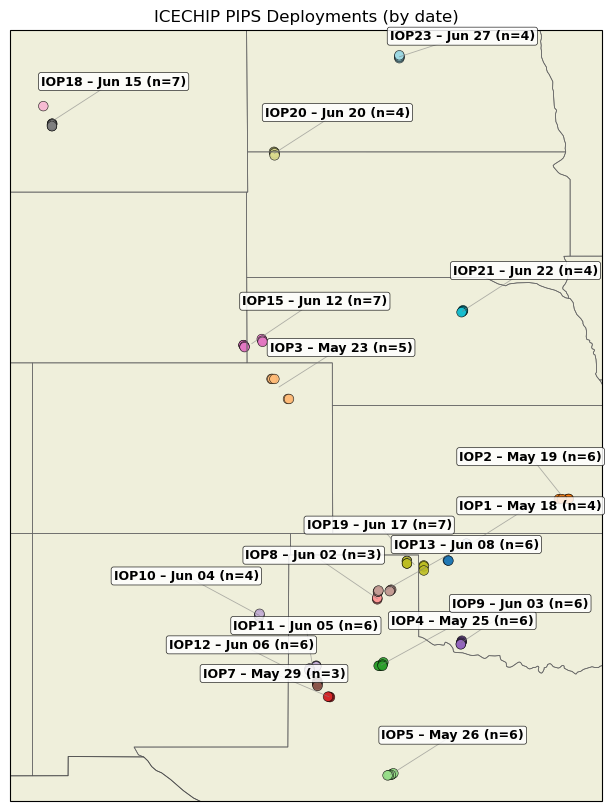

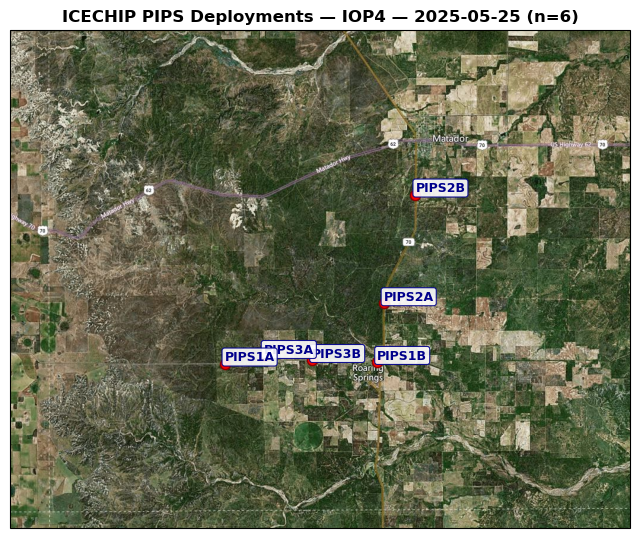

In [4]:
# cimgt.OSM.get_image = image_spoof # reformat web request for street map spoofing
# osm_img = cimgt.OSM() # spoofed, downloaded street map
cimgt.QuadtreeTiles.get_image = image_spoof # reformat web request for street map spoofing
osm_img = cimgt.QuadtreeTiles() # spoofed, downloaded street map

# 1) Point to your files. They’re headerless, like your example.
#    You can pass a list or a glob:

Purdue_deploy_dirname = "/Users/dawson29/Dropbox/Projects/ICECHIP/GURU/Purdue/IOP/"
NSSL_deploy_dirname = "/Users/dawson29/Dropbox/Projects/ICECHIP/GURU/NSSL/"
Purdue_deploy_paths = glob.glob(os.path.join(Purdue_deploy_dirname, "*.txt"))
NSSL_deploy_paths = glob.glob(os.path.join(NSSL_deploy_dirname, "*.txt"))
files = Purdue_deploy_paths + NSSL_deploy_paths

# 2) Read & normalize
df = read_deployments(files, assume_utc=True)
# If you want grouping by a local timezone’s *calendar* day instead,
# convert before extracting df['date'] above. For now we assume UTC.

# 3) Plot all days (color-coded by date, centroid labels)
fig, ax = plot_all_dates(
    df,
    title="ICECHIP PIPS Deployments (by date)",
    output_path="icechip_all_dates.png",
    annotate=True,
    s=48
)
plt.show()

# 4) (Optional) Zoom into a single date and label each probe
fig2, ax2 = plot_single_date_zoomed_osm(
    df, target_date="2025-05-25",
    output_path="icechip_2025-05-25_zoom.png",
    label_each_probe=True
)
plt.show()

In [5]:
# Verify IOP7 is now included
print("IOPs found in dataset:")
iops_found = sorted([iop for iop in df["iop"].unique() if not pd.isna(iop)])
print(f"Total IOPs: {len(iops_found)}")
for iop in iops_found:
    count = len(df[df["iop"] == iop])
    print(f"  {iop}: {count} deployments")

# Check if IOP7 specifically is working
iop7_data = df[df["iop"] == "IOP7"]
if not iop7_data.empty:
    print(f"\nIOP7 details:")
    print(f"  Deployments: {len(iop7_data)}")
    print(f"  Probes: {iop7_data['probe'].unique()}")
    print(f"  Dates: {iop7_data['date'].unique()}")
    print(f"  Sources: {iop7_data['source'].unique()}")
else:
    print("\nIOP7 still not found - may need further investigation")

IOPs found in dataset:
Total IOPs: 18
  IOP1: 4 deployments
  IOP10: 4 deployments
  IOP11: 6 deployments
  IOP12: 6 deployments
  IOP13: 6 deployments
  IOP15: 7 deployments
  IOP18: 7 deployments
  IOP19: 7 deployments
  IOP2: 6 deployments
  IOP20: 4 deployments
  IOP21: 4 deployments
  IOP23: 4 deployments
  IOP3: 5 deployments
  IOP4: 6 deployments
  IOP5: 6 deployments
  IOP7: 3 deployments
  IOP8: 3 deployments
  IOP9: 6 deployments

IOP7 details:
  Deployments: 3
  Probes: ['PIPS1A' 'PIPS3A' 'PIPS3B']
  Dates: ['2025-05-29']
  Sources: ['20250529_213830_DeploymentLog.txt']


In [ ]:
# Diagnostic tools to identify potential outliers and suspicious deployments

def haversine_distance_km(lat1, lon1, lat2, lon2):
    """Calculate the great circle distance between two points in kilometers"""
    # Convert decimal degrees to radians
    lat1_r, lon1_r, lat2_r, lon2_r = map(np.radians, [lat1, lon1, lat2, lon2])

    # Haversine formula
    dlat = lat2_r - lat1_r
    dlon = lon2_r - lon1_r
    a = np.sin(dlat/2)**2 + np.cos(lat1_r) * np.cos(lat2_r) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    # Radius of earth in kilometers
    R = 6371
    return R * c

def analyze_iop_spatial_spread(df, distance_threshold_km=50):
    """
    Analyze spatial spread of deployments within each IOP to identify potential outliers.

    Parameters:
    - df: DataFrame with deployment data
    - distance_threshold_km: Threshold distance in km to flag outliers

    Returns dictionary with IOP analysis results
    """
    results = {}

    for iop in sorted([iop for iop in df["iop"].unique() if not pd.isna(iop)]):
        iop_data = df[df["iop"] == iop].copy()

        if len(iop_data) < 2:
            continue

        # Calculate centroid
        centroid_lat, centroid_lon = great_circle_centroid(
            iop_data["lat"].values, iop_data["lon"].values
        )

        # Calculate distances from centroid for each deployment
        distances = []
        for _, row in iop_data.iterrows():
            dist = haversine_distance_km(centroid_lat, centroid_lon, row["lat"], row["lon"])
            distances.append(dist)

        iop_data = iop_data.copy()
        iop_data["distance_from_centroid_km"] = distances

        # Find outliers
        max_dist = max(distances)
        outliers = iop_data[iop_data["distance_from_centroid_km"] > distance_threshold_km]

        results[iop] = {
            "total_deployments": len(iop_data),
            "max_distance_km": max_dist,
            "centroid": (centroid_lat, centroid_lon),
            "outliers": outliers,
            "dates_spanned": sorted(iop_data["date"].unique()),
            "sources": sorted(iop_data["source"].unique())
        }

    return results

def print_iop_analysis(analysis_results, show_details=True):
    """Print formatted analysis results"""
    print("IOP Spatial Analysis")
    print("=" * 60)

    for iop, results in analysis_results.items():
        max_dist = results["max_distance_km"]
        n_outliers = len(results["outliers"])

        # Flag suspicious IOPs
        flag = ""
        if max_dist > 100:
            flag = " 🚨 VERY WIDE SPREAD"
        elif max_dist > 50:
            flag = " ⚠️  WIDE SPREAD"
        elif n_outliers > 0:
            flag = " ⚠️  HAS OUTLIERS"

        print(f"\n{iop}: {results['total_deployments']} deployments{flag}")
        print(f"  Max distance from centroid: {max_dist:.1f} km")
        print(f"  Dates: {', '.join(results['dates_spanned'])}")
        print(f"  Sources: {len(results['sources'])} files")

        if show_details and n_outliers > 0:
            print(f"  Outliers (>{50}km from centroid):")
            for _, outlier in results["outliers"].iterrows():
                print(f"    {outlier['probe']} at ({outlier['lat']:.4f}, {outlier['lon']:.4f}) "
                      f"- {outlier['distance_from_centroid_km']:.1f}km - {outlier['source']}")

# Run the analysis
print("Analyzing spatial spread of deployments by IOP...")
analysis = analyze_iop_spatial_spread(df, distance_threshold_km=50)
print_iop_analysis(analysis)

In [ ]:
# Look more closely at IOPs with suspiciously wide spreads
suspicious_iops = ['IOP1', 'IOP18', 'IOP3']  # The ones with largest spreads

print("Detailed analysis of suspicious IOPs:")
print("=" * 60)

for iop in suspicious_iops:
    print(f"\n{iop} - Detailed breakdown:")
    iop_data = df[df["iop"] == iop].copy()

    # Calculate centroid
    centroid_lat, centroid_lon = great_circle_centroid(
        iop_data["lat"].values, iop_data["lon"].values
    )

    # Add distances
    distances = []
    for _, row in iop_data.iterrows():
        dist = haversine_distance_km(centroid_lat, centroid_lon, row["lat"], row["lon"])
        distances.append(dist)

    iop_data = iop_data.copy()
    iop_data["distance_from_centroid_km"] = distances
    iop_data = iop_data.sort_values("distance_from_centroid_km", ascending=False)

    print(f"  Centroid: ({centroid_lat:.4f}, {centroid_lon:.4f})")
    print(f"  Deployments ranked by distance from centroid:")

    for _, row in iop_data.iterrows():
        print(f"    {row['probe']}: ({row['lat']:.4f}, {row['lon']:.4f}) "
              f"- {row['distance_from_centroid_km']:.1f}km")
        print(f"      Time: {row['timestamp']} | Source: {row['source']}")

    # Check if there are time-based patterns (e.g., test vs operational deployments)
    print(f"  Time patterns:")
    for source in sorted(iop_data["source"].unique()):
        source_data = iop_data[iop_data["source"] == source]
        time_range = f"{source_data['timestamp'].min()} to {source_data['timestamp'].max()}"
        avg_dist = source_data["distance_from_centroid_km"].mean()
        print(f"    {source}: {len(source_data)} deployments, avg distance {avg_dist:.1f}km")
        print(f"      Time range: {time_range}")

In [ ]:
# Create a visualization function to plot IOP outliers
def plot_iop_outliers(df, iop_name, distance_threshold_km=30):
    """Plot an IOP's deployments with outliers highlighted"""

    iop_data = df[df["iop"] == iop_name].copy()
    if iop_data.empty:
        print(f"No data found for {iop_name}")
        return

    # Calculate centroid and distances
    centroid_lat, centroid_lon = great_circle_centroid(
        iop_data["lat"].values, iop_data["lon"].values
    )

    distances = []
    for _, row in iop_data.iterrows():
        dist = haversine_distance_km(centroid_lat, centroid_lon, row["lat"], row["lon"])
        distances.append(dist)

    iop_data = iop_data.copy()
    iop_data["distance_from_centroid_km"] = distances

    # Separate normal vs outlier deployments
    normal_deployments = iop_data[iop_data["distance_from_centroid_km"] <= distance_threshold_km]
    outlier_deployments = iop_data[iop_data["distance_from_centroid_km"] > distance_threshold_km]

    # Create plot
    proj = ccrs.PlateCarree()
    fig = plt.figure(figsize=(12, 9), constrained_layout=True)
    ax = plt.axes(projection=proj)

    # Background features
    ax.add_feature(cfeature.LAND, zorder=0)
    ax.add_feature(cfeature.OCEAN, zorder=0)
    ax.add_feature(cfeature.STATES.with_scale("50m"), linewidth=0.8, edgecolor="0.4")
    ax.add_feature(cfeature.COASTLINE.with_scale("50m"), linewidth=0.8, edgecolor="0.3")

    # Set extent with extra padding for outliers
    xmin, xmax, ymin, ymax = padded_extent(iop_data, 0.3)
    ax.set_extent([xmin, xmax, ymin, ymax], crs=proj)

    # Plot centroid
    ax.plot(centroid_lon, centroid_lat, 'k*', markersize=20,
            transform=proj, label='Centroid', zorder=10)

    # Plot normal deployments
    if not normal_deployments.empty:
        ax.scatter(normal_deployments["lon"], normal_deployments["lat"],
                  c='green', s=80, alpha=0.8, transform=proj,
                  edgecolor="darkgreen", linewidth=1.5,
                  label=f'Normal ({len(normal_deployments)})', zorder=8)

    # Plot outlier deployments
    if not outlier_deployments.empty:
        ax.scatter(outlier_deployments["lon"], outlier_deployments["lat"],
                  c='red', s=100, alpha=0.9, transform=proj,
                  edgecolor="darkred", linewidth=2, marker='^',
                  label=f'Outliers ({len(outlier_deployments)})', zorder=9)

    # Add labels for all deployments
    for _, row in iop_data.iterrows():
        color = 'red' if row["distance_from_centroid_km"] > distance_threshold_km else 'darkgreen'
        ax.text(row["lon"], row["lat"], f"{row['probe']}\n{row['distance_from_centroid_km']:.1f}km",
               transform=proj, ha="center", va="bottom", fontsize=8,
               color=color, weight="bold",
               bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8),
               zorder=11)

    # Draw circle showing threshold distance
    theta = np.linspace(0, 2*np.pi, 100)
    # Approximate circle in lat/lon (not perfect for large distances, but good enough for visualization)
    lat_radius = distance_threshold_km / 111.0  # degrees latitude per km
    lon_radius = distance_threshold_km / (111.0 * np.cos(np.radians(centroid_lat)))  # adjusted for latitude

    circle_lats = centroid_lat + lat_radius * np.sin(theta)
    circle_lons = centroid_lon + lon_radius * np.cos(theta)
    ax.plot(circle_lons, circle_lats, 'k--', alpha=0.5, transform=proj,
           label=f'{distance_threshold_km}km threshold', zorder=5)

    ax.legend(loc='upper right')
    ax.set_title(f"{iop_name} Deployment Analysis\n"
                f"Max distance: {iop_data['distance_from_centroid_km'].max():.1f}km | "
                f"Outliers (>{distance_threshold_km}km): {len(outlier_deployments)}")

    plt.show()

    return fig, ax

# Plot the most suspicious IOPs
for iop in ['IOP18', 'IOP3', 'IOP1']:
    print(f"\n{'='*50}")
    print(f"Plotting {iop}:")
    plot_iop_outliers(df, iop, distance_threshold_km=30)

In [ ]:
# Create a function to filter out suspected outliers
def create_filtered_dataset(df, outlier_rules=None):
    """
    Create a filtered dataset excluding suspected outliers.

    Parameters:
    - df: Original dataframe
    - outlier_rules: List of dictionaries with filtering rules
      Format: [{'iop': 'IOP18', 'probe': 'PIPS2A', 'reason': 'Too far from cluster'}]

    Returns filtered dataframe and summary of excluded deployments
    """
    if outlier_rules is None:
        # Default rules based on our analysis
        outlier_rules = [
            {'iop': 'IOP18', 'probe': 'PIPS2A', 'reason': 'Outlier: 43.8km from main cluster'}
        ]

    filtered_df = df.copy()
    excluded_deployments = []

    for rule in outlier_rules:
        # Find matching deployments
        mask = (filtered_df['iop'] == rule['iop']) & (filtered_df['probe'] == rule['probe'])
        excluded = filtered_df[mask].copy()

        if not excluded.empty:
            excluded['exclusion_reason'] = rule['reason']
            excluded_deployments.append(excluded)
            # Remove from filtered dataset
            filtered_df = filtered_df[~mask]

    # Combine all excluded deployments
    if excluded_deployments:
        excluded_df = pd.concat(excluded_deployments, ignore_index=True)
    else:
        excluded_df = pd.DataFrame()

    return filtered_df, excluded_df

# Example: Filter out the most obvious outlier
print("Creating filtered dataset...")
filtered_df, excluded_df = create_filtered_dataset(df)

print(f"Original dataset: {len(df)} deployments")
print(f"Filtered dataset: {len(filtered_df)} deployments")
print(f"Excluded: {len(excluded_df)} deployments")

if not excluded_df.empty:
    print("\nExcluded deployments:")
    for _, row in excluded_df.iterrows():
        print(f"  {row['iop']} {row['probe']}: {row['exclusion_reason']}")
        print(f"    Location: ({row['lat']:.4f}, {row['lon']:.4f})")
        print(f"    Time: {row['timestamp']}")
        print(f"    Source: {row['source']}")

# Create comparison plot
print("\nComparing original vs filtered dataset:")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7),
                               subplot_kw={'projection': ccrs.PlateCarree()})

# Original plot
for ax, data, title in [(ax1, df, "Original Dataset"), (ax2, filtered_df, "Filtered Dataset")]:
    # Background
    ax.add_feature(cfeature.LAND, zorder=0)
    ax.add_feature(cfeature.OCEAN, zorder=0)
    ax.add_feature(cfeature.STATES.with_scale("50m"), linewidth=0.5, edgecolor="0.4")
    ax.add_feature(cfeature.COASTLINE.with_scale("50m"), linewidth=0.6, edgecolor="0.3")

    # Plot points
    ax.scatter(data["lon"], data["lat"], s=30, alpha=0.7,
              c='blue', transform=ccrs.PlateCarree(), zorder=5)

    # Set extent
    xmin, xmax, ymin, ymax = padded_extent(data, 0.4)
    ax.set_extent([xmin, xmax, ymin, ymax], crs=ccrs.PlateCarree())

    ax.set_title(f"{title}\n{len(data)} deployments", fontsize=12, fontweight='bold')

# Highlight excluded points on original plot
if not excluded_df.empty:
    ax1.scatter(excluded_df["lon"], excluded_df["lat"], s=100,
               c='red', marker='X', transform=ccrs.PlateCarree(),
               zorder=10, label='Excluded outliers')
    ax1.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Create final plot with filtered data
print("Creating final plot with filtered dataset...")

fig, ax = plot_all_dates(
    filtered_df,
    title="ICECHIP PIPS Deployments (Filtered - Outliers Removed)",
    annotate=True,
    s=48
)
plt.show()

# Run spatial analysis on filtered data
print("\nSpatial analysis of filtered dataset:")
filtered_analysis = analyze_iop_spatial_spread(filtered_df, distance_threshold_km=50)

# Print summary focusing on previously problematic IOPs
problem_iops = ['IOP18', 'IOP3', 'IOP1']
for iop in problem_iops:
    if iop in filtered_analysis:
        results = filtered_analysis[iop]
        print(f"{iop}: Max distance now {results['max_distance_km']:.1f}km "
              f"({results['total_deployments']} deployments)")
    else:
        print(f"{iop}: No data after filtering")

In [ ]:
# Debug: Examine the June 5th case to understand the file structure
print("Files found:")
for f in files:
    if "2025-06-05" in f or "06-05" in f or "0605" in f:
        print(f"  {f}")

# Let's also look at the raw data for June 5th to see the timestamps
df_debug = read_deployments(files, assume_utc=True)
june_5_data = df_debug[df_debug["date"] == "2025-06-05"].copy()
if not june_5_data.empty:
    print(f"\nJune 5th deployments found: {len(june_5_data)}")
    print("Source files and timestamps:")
    for source in june_5_data["source"].unique():
        source_data = june_5_data[june_5_data["source"] == source]
        print(f"\nFile: {source}")
        print(f"  Time range: {source_data['timestamp'].min()} to {source_data['timestamp'].max()}")
        print(f"  IOPs assigned: {source_data['iop'].unique()}")
        print(f"  Probes: {source_data['probe'].unique()}")
else:
    print("\nNo June 5th data found.")

In [ ]:
# Verify IOP assignments are working correctly across all dates
print("Summary of IOP assignments by date:")
print("Date\t\tIOPs\t\tCount")
print("-" * 40)

for date in sorted(df["date"].unique()):
    date_data = df[df["date"] == date]
    iops = date_data["iop"].unique()
    iops = [iop for iop in iops if not pd.isna(iop)]  # Remove NaN values
    count = len(date_data)
    print(f"{date}\t{', '.join(iops)}\t\t{count}")

# Check for any deployments with missing IOP assignments
missing_iop = df[df["iop"].isna()]
if not missing_iop.empty:
    print(f"\nWarning: {len(missing_iop)} deployments have missing IOP assignments:")
    print(missing_iop[["source", "date", "timestamp", "probe"]].to_string())
else:
    print("\nAll deployments have IOP assignments.")

In [ ]:
# Debug: Check for duplicate IOP assignments
print("Checking for duplicate IOP assignments...")
print("\nIOP assignments by deployment date:")
for date in sorted(df["date"].unique()):
    date_data = df[df["date"] == date]
    iops = date_data["iop"].unique()
    iops = [iop for iop in iops if not pd.isna(iop)]
    if iops:
        print(f"{date}: {', '.join(iops)}")

print("\n" + "="*50)
print("Deployment dates by IOP:")
iop_to_dates = {}
for date in sorted(df["date"].unique()):
    date_data = df[df["date"] == date]
    for iop in date_data["iop"].unique():
        if not pd.isna(iop):
            if iop not in iop_to_dates:
                iop_to_dates[iop] = []
            if date not in iop_to_dates[iop]:
                iop_to_dates[iop].append(date)

for iop in sorted(iop_to_dates.keys()):
    dates = sorted(iop_to_dates[iop])
    if len(dates) > 1:
        print(f"⚠️  {iop}: {', '.join(dates)} (MULTIPLE DATES)")
    else:
        print(f"   {iop}: {dates[0]}")

print("\n" + "="*50)
print("Check iop_by_date dictionary for duplicates:")
iop_counts = {}
for date, iop in iop_by_date.items():
    if iop not in iop_counts:
        iop_counts[iop] = []
    iop_counts[iop].append(date)

print("IOPs assigned to multiple dates in dictionary:")
for iop, dates in iop_counts.items():
    if len(dates) > 1:
        print(f"⚠️  {iop}: {', '.join(dates)}")
    else:
        print(f"   {iop}: {dates[0]}")

In [ ]:
# Let's examine the specific cases of overlapping IOPs more closely
print("Detailed analysis of problematic dates:")

# Check June 5th (IOP10 and IOP11)
june_5_data = df[df["date"] == "2025-06-05"]
print(f"\n2025-06-05 data:")
print(f"  Total deployments: {len(june_5_data)}")
for iop in june_5_data["iop"].unique():
    if not pd.isna(iop):
        iop_data = june_5_data[june_5_data["iop"] == iop]
        print(f"  {iop}: {len(iop_data)} deployments")
        print(f"    Time range: {iop_data['timestamp'].min()} to {iop_data['timestamp'].max()}")
        print(f"    Sources: {iop_data['source'].unique()}")

# Check May 19th (IOP1 extension)
may_19_data = df[df["date"] == "2025-05-19"]
if not may_19_data.empty:
    print(f"\n2025-05-19 data (IOP1 extension):")
    print(f"  Total deployments: {len(may_19_data)}")
    for iop in may_19_data["iop"].unique():
        if not pd.isna(iop):
            iop_data = may_19_data[may_19_data["iop"] == iop]
            print(f"  {iop}: {len(iop_data)} deployments")
            print(f"    Time range: {iop_data['timestamp'].min()} to {iop_data['timestamp'].max()}")

# Check June 16th (IOP18 extension)
june_16_data = df[df["date"] == "2025-06-16"]
if not june_16_data.empty:
    print(f"\n2025-06-16 data (IOP18 extension):")
    print(f"  Total deployments: {len(june_16_data)}")
    for iop in june_16_data["iop"].unique():
        if not pd.isna(iop):
            iop_data = june_16_data[june_16_data["iop"] == iop]
            print(f"  {iop}: {len(iop_data)} deployments")
            print(f"    Time range: {iop_data['timestamp'].min()} to {iop_data['timestamp'].max()}")

In [ ]:
# Test the groupby logic that the plotting function uses
print("Testing IOP grouping logic:")
print("Unique IOPs in dataset:", sorted([iop for iop in df["iop"].unique() if not pd.isna(iop)]))

print("\nGrouping by IOP only:")
for iop, sub in df.groupby("iop"):
    if pd.isna(iop):
        continue
    dates_in_group = sub["date"].unique()
    print(f"{iop}: {len(sub)} deployments across dates {sorted(dates_in_group)}")

# Check if there are any issues with the groupby itself
print(f"\nTotal deployments: {len(df)}")
print(f"Deployments by IOP count: {df.groupby('iop').size().sum()}")  # Should match total

In [ ]:
# Create a fresh plot to test the fixed function
plt.close('all')  # Close any existing plots

fig, ax = plot_all_dates(
    df,
    title="ICECHIP PIPS Deployments (FIXED - grouped by IOP only)",
    annotate=True,
    s=48
)
plt.show()

print(f"Plot created with {len([iop for iop in df['iop'].unique() if not pd.isna(iop)])} unique IOPs")

In [ ]:
# Debug: Print what labels the function would create without plotting
print("Labels that would be created:")
for iop, sub in df.groupby("iop"):
    if pd.isna(iop):
        continue

    # Find the IOP start date from the iop_by_date dictionary
    iop_start_date = None
    for date_key, iop_value in iop_by_date.items():
        if iop_value == iop:
            iop_start_date = date_key
            break

    if iop_start_date:
        date_short = pd.to_datetime(iop_start_date).strftime("%b %d")
    else:
        earliest_date = sub["date"].min()
        date_short = pd.to_datetime(earliest_date).strftime("%b %d")

    label = f"{iop} – {date_short} (n={len(sub)})"
    dates_spanned = sorted(sub["date"].unique())
    print(f"  {label} - spans dates: {dates_spanned}")

print(f"\nTotal labels to create: {len([iop for iop in df['iop'].unique() if not pd.isna(iop)])}")

In [ ]:
# Test with freshly reloaded function
plt.close('all')

fig, ax = plot_all_dates(
    df,
    title="ICECHIP PIPS Deployments (After Function Reload)",
    annotate=True,
    s=48
)
plt.show()